# Predictive Model Development for International Football Matches

This project aims to build a Machine Learning model capable of predicting football match outcomes (Home Win, Draw, or Away Win). 

The main technical differentiator of this approach is the construction of a strictly chronological data engineering pipeline. Instead of using static averages that would cause future information to leak into the past (Data Leakage), the algorithm iterates through the match history creating a dynamic "notebook". This ensures the model makes decisions based solely on information available right before kickoff.

## 1. Imports and Data Loading
Environment setup and initial DataFrame structuring, ensuring the correct temporal typing for match dates.

In [60]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


In [61]:
df = pd.read_csv('results.csv')
df.head()
df['date'] = pd.to_datetime(df['date'])

## 2. Target Variable Definition
The business problem was modeled as a **Multiclass Classification** task. From historical scores, we derived the match outcome from the home team's perspective: `home_win`, `away_win`, or `tie` (draw).

In [62]:
conditions = [
    df['home_score'] > df['away_score'],
    df['home_score'] < df['away_score'],
    df['home_score'] == df['away_score']
]

results = [
    'home_win',
    'away_win',
    'tie'
]

df['Target'] = np.select(conditions, results, default='Error')
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,Target
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,tie
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,home_win
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,home_win
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,tie
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,home_win


## 3. Feature Engineering I: Head-to-Head (H2H) History
For the model to understand the rivalry or dominance between two teams, we need to extract their Head-to-Head (H2H) history. 

To avoid data leakage, the data was sorted chronologically and the history is calculated at runtime. The model reads the team's strength *before* the match occurs, saves this "snapshot" for the algorithm to study later, and only post-match is the current score added to the history for future matchups.

In [63]:
# old -> new
df = df.sort_values('date').reset_index(drop=True)

h2h_historic = {}

h2h_home_wins = []
h2h_away_wins = []
h2h_ties = []

for index, row in df.iterrows():
    home = row['home_team']
    away = row['away_team']
    target = row['Target']
    
    game = tuple(sorted([home, away]))
    
    # if first game
    if game not in h2h_historic:
        h2h_historic[game] = {home: 0, away: 0, 'tie': 0}
        
    h2h_home_wins.append(h2h_historic[game][home])
    h2h_away_wins.append(h2h_historic[game][away])
    h2h_ties.append(h2h_historic[game]['tie'])
    
    # updates
    if target == 'home_win':
        h2h_historic[game][home] += 1
    elif target == 'away_win':
        h2h_historic[game][away] += 1
    elif target == 'tie':
        h2h_historic[game]['tie'] += 1

# back to pandas
df['h2h_home_wins'] = h2h_home_wins
df['h2h_away_wins'] = h2h_away_wins
df['h2h_ties'] = h2h_ties

## 4. Feature Engineering II: The "Momentum" Factor (8-Year Sliding Window)
A national team's performance 20 years ago holds little weight regarding its current strength. To capture the *Momentum* (current form) of each team, we implemented a Sliding Window algorithm.

For each match, the algorithm scans the history of those two teams and applies a strict filter: **only goals scored and conceded in the last 8 years are counted**. Goals outside this time limit are dynamically discarded from the team's memory, keeping the strength metric consistently updated and relevant.

In [64]:
teams_historic = {}

home_scored_col = []
home_conceded_col = []
away_scored_col = []
away_conceded_col = []

for index, row in df.iterrows():
    home_score = row['home_score']
    away_score = row['away_score']
    game_date = row['date']

    home = row['home_team']
    away = row['away_team']
    if home not in teams_historic:
        teams_historic[home] = []
    if away not in teams_historic:
        teams_historic[away] = []

    eight_years_limit = game_date - pd.DateOffset(years=8)
    teams_historic[home] = [ game for game in teams_historic[home] if game['date'] > eight_years_limit]
    teams_historic[away] = [ game for game in teams_historic[away] if game['date'] > eight_years_limit]

    home_scored_goals = 0
    home_conceded_goals = 0
    for g in teams_historic[home]:
        home_scored_goals += g['scored']
        home_conceded_goals += g['conceded']

    away_scored_goals = 0
    away_conceded_goals = 0
    for g in teams_historic[away]:
        away_scored_goals += g['scored']
        away_conceded_goals += g['conceded']

    home_scored_col.append(home_scored_goals)
    home_conceded_col.append(home_conceded_goals)
    away_scored_col.append(away_scored_goals)
    away_conceded_col.append(away_conceded_goals)

    teams_historic[home].append({'date': game_date, 'scored': home_score, 'conceded': away_score})
    teams_historic[away].append({'date': game_date, 'scored': away_score, 'conceded': home_score})

df['home_scored'] = home_scored_col
df['home_conceded'] = home_conceded_col
df['away_scored'] = away_scored_col
df['away_conceded'] = away_conceded_col

    


In [65]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,Target,h2h_home_wins,h2h_away_wins,h2h_ties,home_scored,home_conceded,away_scored,away_conceded
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,tie,0,0,0,0.0,0.0,0.0,0.0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,home_win,0,0,1,0.0,0.0,0.0,0.0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,home_win,0,1,1,2.0,4.0,4.0,2.0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,tie,1,1,1,5.0,4.0,4.0,5.0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,home_win,1,1,2,6.0,7.0,7.0,6.0


## 5. Data Leakage Prevention and Feature Selection
With our historical base consolidated, it is crucial to remove variables that could corrupt the model's learning process:
1. **Useless/Textual Variables:** `tournament`, `city`, `country`, `neutral` (Do not add direct mathematical value at this stage).
2. **Already Represented Variables:** `date`, `home_team`, `away_team` (The intelligence from these columns has already been extracted into the numeric Momentum and H2H indices).
3. **Fatal Data Leakage:** `home_score` and `away_score`. If we pass the match score to the model during training, it won't learn to predict the game; it will merely memorize that whoever scores more goals wins. They must be dropped immediately.

In [66]:
# useless
df = df.drop(columns=['tournament', 'city', 'country', 'neutral'])

# no need anymore
df = df.drop(columns=['date', 'home_team', 'away_team'])

# data leak
df = df.drop(columns=['home_score', 'away_score'])

In [67]:
df.head()

,Target,h2h_home_wins,h2h_away_wins,h2h_ties,home_scored,home_conceded,away_scored,away_conceded
0,tie,0,0,0,0.0,0.0,0.0,0.0
1,home_win,0,0,1,0.0,0.0,0.0,0.0
2,home_win,0,1,1,2.0,4.0,4.0,2.0
3,tie,1,1,1,5.0,4.0,4.0,5.0
4,home_win,1,1,2,6.0,7.0,7.0,6.0


## 6. Handling Missing Data
Ensuring the mathematical integrity of the dataset by removing matches that lack sufficient prior history or have recording flaws in the original database.

In [68]:
df = df.dropna()

## 7. Train-Test Split (Production Simulation)
To validate the model's generalization capabilities, we split the dataset, keeping 30% of the matches "hidden" (Test Data). Saving to `.csv` simulates data persistence in a production environment for later consumption.

In [69]:
df_train, df_test = train_test_split(df, train_size=0.7, random_state=60)

df_train.to_csv('df_train.csv', index=False)
df_test.to_csv('df_test.csv', index=False)

## 8. Feature (X) and Target (y) Segmentation
We load the datasets independently to ensure total isolation between the learning environment and the validation environment.

In [70]:
df_train = pd.read_csv('df_train.csv')
df_train.head()

X_train = df_train.drop(columns='Target')
y_train = df_train['Target']


In [71]:
df_test = pd.read_csv('df_test.csv')
df_test.head()

X_test = df_test.drop(columns='Target')
y_test = df_test['Target']

## 9. Baseline Modeling: Logistic Regression
Due to the large scale variation between the History variables (0 to 5) and the Momentum variables (0 to 150+), we implemented the `StandardScaler` to optimize the Gradient Descent, allowing the model to converge quickly. 

We started testing with a Baseline Classification model (Logistic Regression) to obtain a primary performance metric on the complex scenario of sports result prediction.

In [72]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, C=0.1)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)
model_accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {model_accuracy * 100:.2f}%")
 
 

Model Accuracy: 55.30%


⚽ MODEL PREVISION: Brazil vs Argentina
➡️ RESULT (Error): 0.0%
➡️ RESULT (away_win): 20.8%
➡️ RESULT (home_win): 32.7%
➡️ RESULT (tie): 46.5%


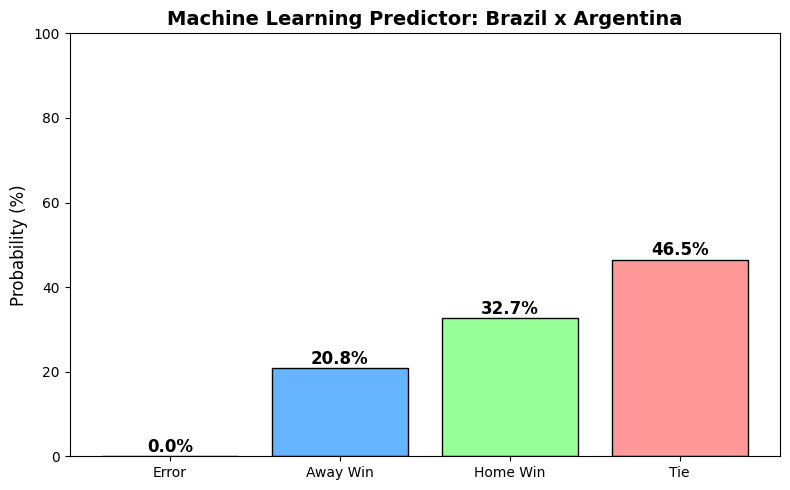

In [73]:
def predict_game(home_team, away_team, df_og, model, standardizer, train_cols):
    """
    Function to predict the outcome between two selections.
    Automatically retrieves historical data and momentum from the database.
    """
    
    game = tuple(sorted([home_team, away_team]))
    
    if game in h2h_historic:
        h2h_home = h2h_historic[game].get(home_team, 0)
        h2h_away = h2h_historic[game].get(away_team, 0)
        h2h_tie = h2h_historic[game].get('tie', 0)
    else:
        # if first game
        h2h_home, h2h_away, h2h_tie = 0, 0, 0
        
    today = df_og['date'].max()
    eight_years = today - pd.DateOffset(years=8)
    
    def today_strengh(team):
        goals_scored, goals_conceded = 0, 0
        if team in teams_historic:
            for match in teams_historic[team]:
                if match['date'] > eight_years:
                    if pd.notna(match['scored']) and pd.notna(match['conceded']):
                        goals_scored += match['scored']
                        goals_conceded += match['conceded']
        return goals_scored, goals_conceded
    
    home_scored, home_conceded = today_strengh(home_team)
    away_scored, away_conceded = today_strengh(away_team)
    
    game_data = pd.DataFrame([[
        h2h_home, h2h_away, h2h_tie, 
        home_scored, home_conceded, 
        away_scored, away_conceded
    ]], columns=train_cols)
    
    std_data = standardizer.transform(game_data)
    proba = model.predict_proba(std_data)[0]
    classes = model.classes_
    
    print(f"⚽ MODEL PREVISION: {home_team} vs {away_team}\n" + "="*45)
    for c, prob in zip(classes, proba):
        print(f"➡️ RESULT ({c}): {prob * 100:.1f}%")
        
    fig, ax = plt.subplots(figsize=(8, 5))
    cores = ['#ff9999', '#66b3ff', '#99ff99']
    
    labels = [c.replace('_win', ' Win').title() for c in classes]
    
    ax.bar(labels, proba * 100, color=cores, edgecolor='black')
    
    for i, prob in enumerate(proba * 100):
        ax.text(i, prob + 1, f"{prob:.1f}%", ha='center', fontweight='bold', fontsize=12)
        
    ax.set_ylabel('Probability (%)', fontsize=12)
    ax.set_title(f'Machine Learning Predictor: {home_team} x {away_team}', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.show()

df_raw = pd.read_csv('results.csv')
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.dropna()

predict_game('Brazil', 'Argentina', df_raw, log_model, scaler, X_train.columns)